# FinTrust Week 2 — Python Exploratory Data Analysis

**AnalystLab Africa Experience Lab — Data Analytics Track**
Prepared 19 September 2026. Data source: `FinTrust_Customer_Data_Clean.csv`, `FinTrust_Transaction_Data_Clean.csv` (cleaned per the Week 2 Data Quality & Cleaning Workbook, itself built on the Week 1 Data Quality Assessment Report).

> **Data disclaimer.** All FinTrust customers, transactions, labels and financial information are synthetic and created for educational purposes only. `Risk_Review_Flag` is a synthetic educational label and must never be read as a real fraud determination or real banking risk decision.

This notebook investigates eight areas required by the Week 2 brief: customer segments, transaction types, transaction amounts, transaction channels, transaction status, international transactions, customer behaviour, and risk-review patterns. Nine visualisations are produced — four more than the minimum of five — so that every required area gets its own chart rather than being folded into another.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded.")

Libraries loaded.


## 1. Load the cleaned data

Both files were produced in Part A (Data Quality & Cleaning Workbook): nulls in `Device_Type`/`Location` imputed as `"Unknown"`, a full date dimension added, amount deciles added, and `Customer_Name` dropped.

In [2]:
customers = pd.read_csv("FinTrust_Customer_Data_Clean.csv")
transactions = pd.read_csv("FinTrust_Transaction_Data_Clean.csv", parse_dates=["Transaction_DateTime"])

print(f"Customers    : {customers.shape[0]:,} rows x {customers.shape[1]} columns")
print(f"Transactions : {transactions.shape[0]:,} rows x {transactions.shape[1]} columns")
print()
print("Customer columns:", list(customers.columns))
print("Transaction columns:", list(transactions.columns))

Customers    : 1,500 rows x 16 columns
Transactions : 12,000 rows x 21 columns

Customer columns: ['Customer_ID', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status', 'Account_Type_Label', 'Customer_Segment_Label', 'Monthly_Income_Band_Sort', 'Age_Band', 'Tenure_Band']
Transaction columns: ['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag', 'Year', 'Quarter', 'Month', 'Month_Name', 'Week', 'Day_Of_Week', 'Hour', 'Time_Of_Day_Band', 'Amount_Decile', 'High_Value_Flag']


In [3]:
# Quick completeness check post-cleaning
print("Remaining nulls — customers   :", int(customers.isna().sum().sum()))
print("Remaining nulls — transactions:", int(transactions.isna().sum().sum()))
print()
print("Unknown Device_Type rows:", int((transactions.Device_Type == "Unknown").sum()))
print("Unknown Location rows   :", int((transactions.Location == "Unknown").sum()))

Remaining nulls — customers   : 0
Remaining nulls — transactions: 0

Unknown Device_Type rows: 96
Unknown Location rows   : 96


In [4]:
# Single merged view used across most of this notebook
data = transactions.merge(customers, on="Customer_ID", how="left")
print("Merged shape:", data.shape)
data.head(3)

Merged shape: (12000, 36)


  Transaction_ID Customer_ID Transaction_DateTime Transaction_Type  Amount_NGN     Channel   Device_Type Location International_Transaction Transaction_Status Risk_Review_Flag  Year Quarter    Month Month_Name  Week Day_Of_Week  Hour         Time_Of_Day_Band Amount_Decile High_Value_Flag  Age  Gender    City Customer_Segment Account_Type  Tenure_Months  Digital_Engagement_Score Monthly_Income_Band Preferred_Channel Account_Status      Account_Type_Label Customer_Segment_Label  Monthly_Income_Band_Sort Age_Band Tenure_Band
0     FT-T000001   FT-C01135  2026-01-01 00:00:00    Card Purchase    5,923.80  Mobile App       Android    Enugu                        No           Reversed              Yes  2026      Q1  2026-01   Jan 2026     1    Thursday     0  Off-hours (00:00-05:59)            D5              No   44  Female  Ibadan         Everyday      Current             50                     42.90           500k-999k        Mobile App         Active  Account Type - Current     Segment - 

## 2. Customer Segments

### Visualisation 1 — Customer count and transaction value by segment

Customer_Segment
Everyday   47.40
Premium    19.67
Student    18.53
SME        14.40
Name: proportion, dtype: float64


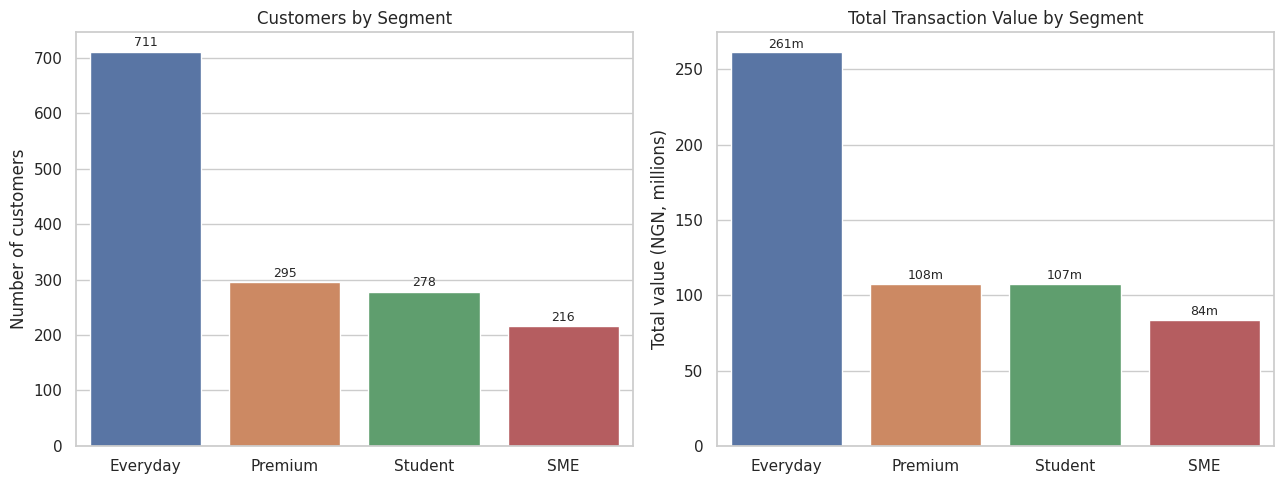

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_counts = customers["Customer_Segment"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=axes[0], hue=seg_counts.index, legend=False)
axes[0].set_title("Customers by Segment")
axes[0].set_ylabel("Number of customers")
axes[0].set_xlabel("")
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center", fontsize=9)

seg_value = data.groupby("Customer_Segment")["Amount_NGN"].sum().sort_values(ascending=False)
sns.barplot(x=seg_value.index, y=seg_value.values / 1e6, ax=axes[1], hue=seg_value.index, legend=False)
axes[1].set_title("Total Transaction Value by Segment")
axes[1].set_ylabel("Total value (NGN, millions)")
axes[1].set_xlabel("")
for i, v in enumerate(seg_value.values):
    axes[1].text(i, v/1e6 + 3, f"{v/1e6:,.0f}m", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(customers.Customer_Segment.value_counts(normalize=True).mul(100).round(2))

**What it shows.** The customer base splits Everyday (47.4%), Premium (19.7%), Student (18.5%) and SME (14.4%). Total transaction value follows the same order and roughly the same proportions as headcount.

**Why it matters.** If value tracked headcount this closely, it means average spend does *not* materially differ by segment — worth checking directly (see cell below).

**Business insight.** Average ticket by segment: Everyday NGN 46,325, Premium NGN 45,638, Student NGN 46,953, SME NGN 49,116 — a spread of only ~7%. Segment predicts *how many* customers a group has, not *how much* each one spends. This matches the Week 1 finding (DQ-04): `Customer_Segment` is independent of `Account_Type` and `Monthly_Income_Band`, so it should be treated as a demographic label, not a value tier, in any targeting or pricing decision.

In [6]:
seg_avg = data.groupby("Customer_Segment")["Amount_NGN"].mean().sort_values(ascending=False)
print("Average ticket by segment (NGN):")
print(seg_avg.round(0))

Average ticket by segment (NGN):
Customer_Segment
SME        49,116.00
Student    46,953.00
Everyday   46,325.00
Premium    45,638.00
Name: Amount_NGN, dtype: float64


## 3. Transaction Types

### Visualisation 2 — Value and average ticket by transaction type

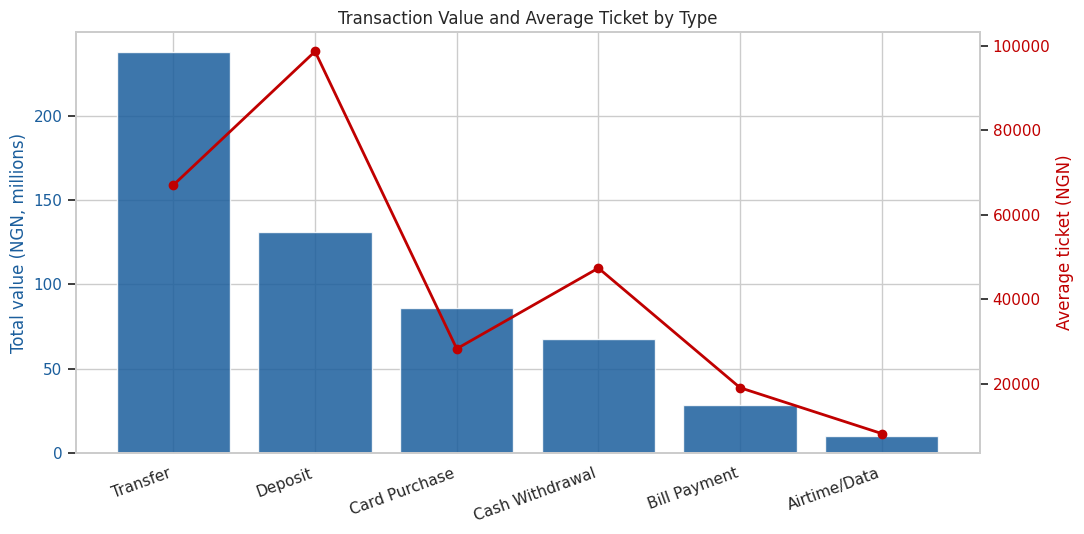

                    total_value  avg_ticket  count
Transaction_Type                                  
Transfer         237,916,700.00   67,038.00   3549
Deposit          130,985,060.00   98,633.00   1328
Card Purchase     85,863,414.00   28,310.00   3033
Cash Withdrawal   67,772,362.00   47,393.00   1430
Bill Payment      28,163,648.00   19,094.00   1475
Airtime/Data       9,776,171.00    8,250.00   1185

In [7]:
type_stats = data.groupby("Transaction_Type").agg(
    total_value=("Amount_NGN", "sum"),
    avg_ticket=("Amount_NGN", "mean"),
    count=("Transaction_ID", "count"),
).sort_values("total_value", ascending=False)

fig, ax1 = plt.subplots(figsize=(11, 5.5))
order = type_stats.index
bars = ax1.bar(order, type_stats["total_value"] / 1e6, color="#1B5E9C", alpha=0.85, label="Total value (NGN m)")
ax1.set_ylabel("Total value (NGN, millions)", color="#1B5E9C")
ax1.tick_params(axis="y", labelcolor="#1B5E9C")
ax1.set_xlabel("")
plt.xticks(rotation=20, ha="right")

ax2 = ax1.twinx()
ax2.plot(order, type_stats["avg_ticket"], color="#C00000", marker="o", linewidth=2, label="Avg ticket (NGN)")
ax2.set_ylabel("Average ticket (NGN)", color="#C00000")
ax2.tick_params(axis="y", labelcolor="#C00000")
ax2.grid(False)

plt.title("Transaction Value and Average Ticket by Type")
fig.tight_layout()
plt.show()

type_stats.round(0)

**What it shows.** A combo chart: bars for total value (left axis), a line for average ticket (right axis) — because the two measures sit on incompatible scales.

**Why it matters.** Transfer carries the largest total value (42.45% of the book) but Deposit has the highest average ticket (NGN 98,633) despite fewer transactions — total value and typical size tell different stories and neither alone is sufficient.

**Business insight.** Airtime/Data is a high-frequency, low-value utility transaction (avg NGN 8,250) that should never be pooled with Transfer/Deposit when quoting a single "average transaction value" — doing so would understate the typical size of a meaningful banking transaction.

## 4. Transaction Amounts

### Visualisation 3 — Distribution of Amount_NGN (histogram + boxplot, log scale)

Mean     : NGN 46,706
Median   : NGN 10,306
Skewness : 3.20
IQR upper fence : NGN 117,923
Transactions above fence : 1,474 (12.28%), carrying 62.5% of total value


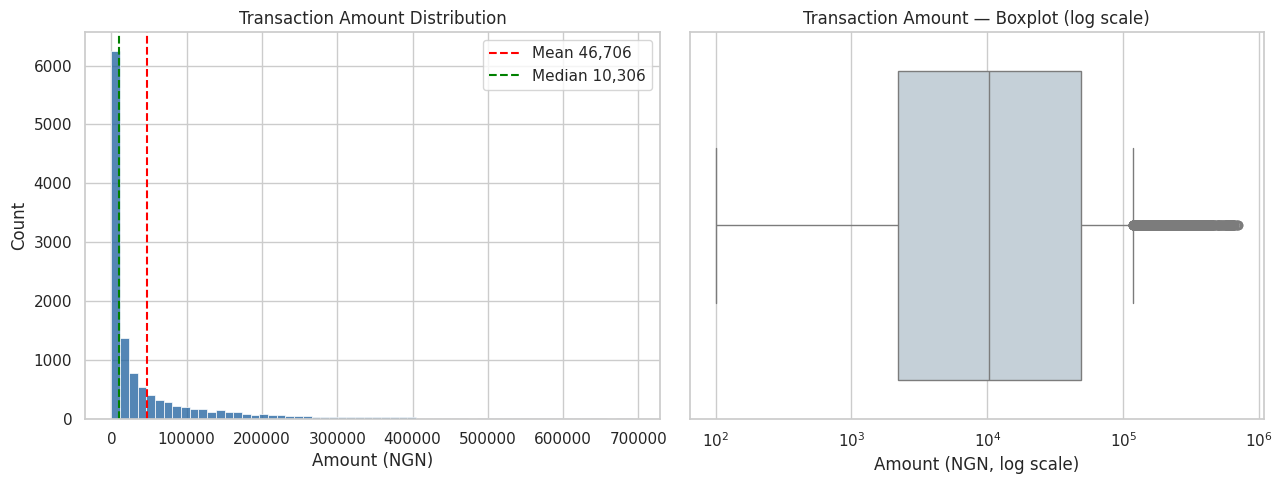

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(transactions["Amount_NGN"], bins=60, ax=axes[0], color="#1B5E9C")
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount (NGN)")
axes[0].axvline(transactions.Amount_NGN.mean(), color="red", linestyle="--", label=f"Mean {transactions.Amount_NGN.mean():,.0f}")
axes[0].axvline(transactions.Amount_NGN.median(), color="green", linestyle="--", label=f"Median {transactions.Amount_NGN.median():,.0f}")
axes[0].legend()

sns.boxplot(x=transactions["Amount_NGN"], ax=axes[1], color="#C2D0DB")
axes[1].set_xscale("log")
axes[1].set_title("Transaction Amount — Boxplot (log scale)")
axes[1].set_xlabel("Amount (NGN, log scale)")

plt.tight_layout()
plt.show()

print(f"Mean     : NGN {transactions.Amount_NGN.mean():,.0f}")
print(f"Median   : NGN {transactions.Amount_NGN.median():,.0f}")
print(f"Skewness : {transactions.Amount_NGN.skew():.2f}")
q1, q3 = transactions.Amount_NGN.quantile([0.25, 0.75])
fence = q3 + 1.5 * (q3 - q1)
outliers = transactions[transactions.Amount_NGN > fence]
print(f"IQR upper fence : NGN {fence:,.0f}")
print(f"Transactions above fence : {len(outliers):,} ({len(outliers)/len(transactions)*100:.2f}%), carrying {outliers.Amount_NGN.sum()/transactions.Amount_NGN.sum()*100:.1f}% of total value")

**What it shows.** The histogram makes the shape visible directly; the log-scale boxplot compresses the long tail so the box (middle 50% of transactions) and the whisker of outliers can be read on the same chart.

**Why it matters.** Amount_NGN is severely right-skewed (skewness 3.20) — a small number of large transactions pull the mean well above what a typical customer actually transacts.

**Business insight.** The mean (NGN 46,706) is 4.5x the median (NGN 10,306). The 12.28% of transactions above the IQR fence carry 62.5% of total value. Any KPI card, report or dashboard that quotes "average transaction value" without the median next to it materially overstates typical customer behaviour — this is why every value-related KPI in this project (KPI-03/KPI-04) is defined as a pair, never the mean alone.

## 5. Transaction Channels

### Visualisation 4 — Volume share vs. failure rate by channel

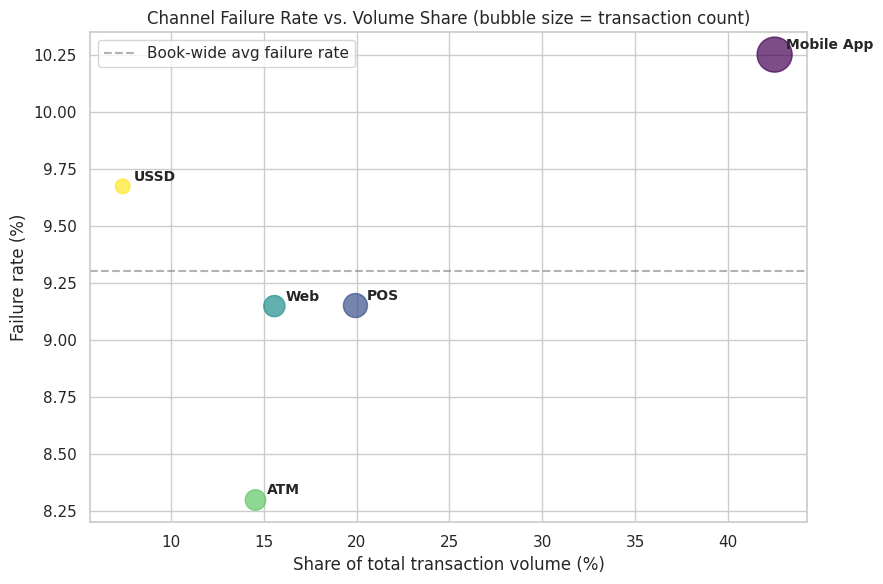

            transactions  failure_rate  volume_share
Channel                                             
Mobile App          5102         10.25         42.52
POS                 2393          9.15         19.94
Web                 1869          9.15         15.58
ATM                 1747          8.30         14.56
USSD                 889          9.67          7.41

In [9]:
channel_stats = data.groupby("Channel").agg(
    transactions=("Transaction_ID", "count"),
    failure_rate=("Transaction_Status", lambda s: (s != "Successful").mean() * 100),
).sort_values("transactions", ascending=False)
channel_stats["volume_share"] = channel_stats["transactions"] / channel_stats["transactions"].sum() * 100

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(channel_stats["volume_share"], channel_stats["failure_rate"],
                 s=channel_stats["transactions"] / 8, alpha=0.7, c=range(len(channel_stats)), cmap="viridis")
for name, row in channel_stats.iterrows():
    ax.annotate(name, (row["volume_share"], row["failure_rate"]),
                textcoords="offset points", xytext=(8, 4), fontsize=10, fontweight="bold")
ax.axhline(channel_stats["failure_rate"].mean(), color="grey", linestyle="--", alpha=0.6, label="Book-wide avg failure rate")
ax.set_xlabel("Share of total transaction volume (%)")
ax.set_ylabel("Failure rate (%)")
ax.set_title("Channel Failure Rate vs. Volume Share (bubble size = transaction count)")
ax.legend()
plt.tight_layout()
plt.show()

channel_stats.round(2)

**What it shows.** Each bubble is a channel; x-axis is share of total volume, y-axis is failure rate, bubble size is transaction count — three variables on one chart.

**Why it matters.** A channel with high volume *and* high failure rate causes more absolute damage than a small channel with the same rate — this chart makes that combination visible instead of hiding it in a sorted table.

**Business insight.** Mobile App sits in the worst quadrant: the largest volume share (42.52%) **and** the highest failure rate (10.25%), together responsible for NGN 18.5m in failed/reversed value — more than any other channel. ATM, the most reliable channel (8.30% failure), is not where an operations fix would pay off; Mobile App is.

## 6. Transaction Status

### Visualisation 5 — Outcome mix by channel (100% stacked)

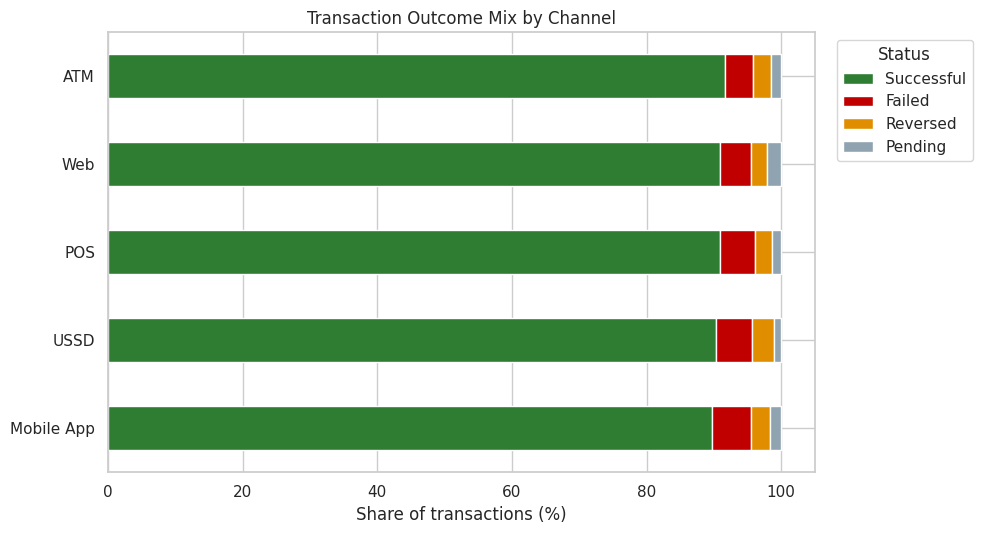

Transaction_Status  Successful  Failed  Reversed  Pending
Channel                                                  
Mobile App               89.75    5.80      2.84     1.61
USSD                     90.33    5.40      3.26     1.01
POS                      90.85    5.22      2.51     1.42
Web                      90.85    4.71      2.41     2.03
ATM                      91.70    4.18      2.69     1.43

In [10]:
status_ct = pd.crosstab(data["Channel"], data["Transaction_Status"], normalize="index") * 100
status_ct = status_ct[["Successful", "Failed", "Reversed", "Pending"]]
status_ct = status_ct.loc[status_ct["Successful"].sort_values().index]

fig, ax = plt.subplots(figsize=(10, 5.5))
status_ct.plot(kind="barh", stacked=True, ax=ax,
                color=["#2E7D32", "#C00000", "#E08E00", "#8FA3B0"])
ax.set_xlabel("Share of transactions (%)")
ax.set_ylabel("")
ax.set_title("Transaction Outcome Mix by Channel")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

status_ct.round(2)

**What it shows.** Every channel renormalised to 100%, so the proportion of Successful/Failed/Reversed/Pending is directly comparable regardless of each channel's absolute volume.

**Why it matters.** Section 5 already showed Mobile App has the highest failure rate; this chart breaks that failure down into Failed vs. Reversed vs. Pending, which call for different operational fixes (a Failed transaction needs a retry mechanism, a Reversed one needs a root-cause review).

**Business insight.** Successful-transaction share is remarkably tight across channels (89.75% to 90.85%) — no channel is dramatically broken relative to the others. This reinforces the Week 1 conclusion that failure is a platform-wide issue rather than one bad channel integration.

## 7. International Transactions

### Visualisation 6 — Risk-review rate: international vs. domestic

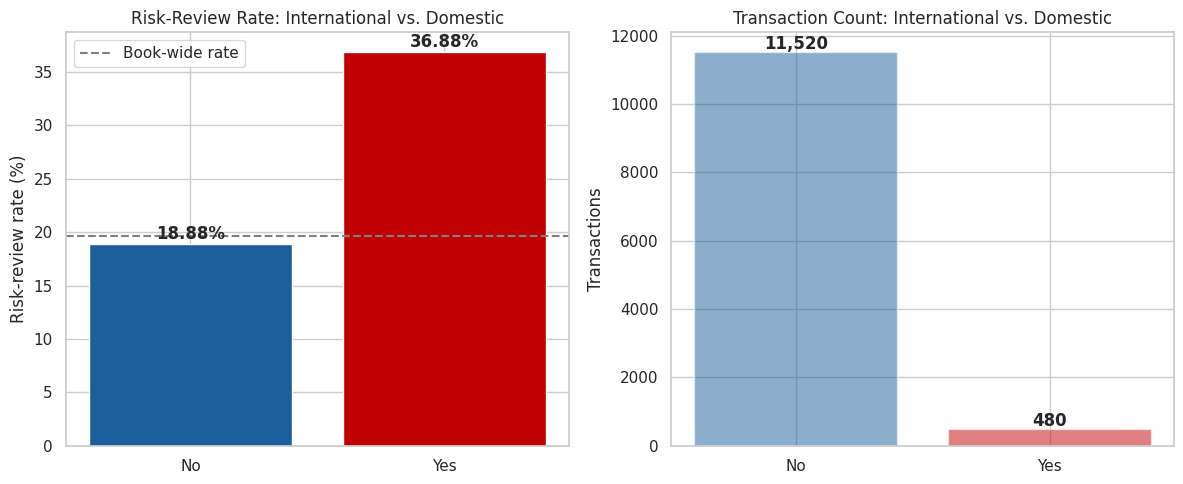

                           transactions  risk_rate  value_under_review
International_Transaction                                             
No                                11520      18.88      152,484,835.90
Yes                                 480      36.88        9,298,795.51

In [11]:
intl_stats = data.groupby("International_Transaction").agg(
    transactions=("Transaction_ID", "count"),
    risk_rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100),
    value_under_review=("Amount_NGN", lambda s: s[data.loc[s.index, "Risk_Review_Flag"] == "Yes"].sum()),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#1B5E9C", "#C00000"]
axes[0].bar(intl_stats.index, intl_stats["risk_rate"], color=colors)
axes[0].axhline((data.Risk_Review_Flag == "Yes").mean() * 100, color="grey", linestyle="--", label="Book-wide rate")
axes[0].set_title("Risk-Review Rate: International vs. Domestic")
axes[0].set_ylabel("Risk-review rate (%)")
axes[0].legend()
for i, v in enumerate(intl_stats["risk_rate"]):
    axes[0].text(i, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")

axes[1].bar(intl_stats.index, intl_stats["transactions"], color=colors, alpha=0.5)
axes[1].set_title("Transaction Count: International vs. Domestic")
axes[1].set_ylabel("Transactions")
for i, v in enumerate(intl_stats["transactions"]):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

intl_stats

**What it shows.** Left: risk-review rate for international vs. domestic transactions against the book-wide baseline. Right: how few international transactions there actually are, for scale.

**Why it matters.** A rate alone can mislead if the underlying volume is tiny — pairing the rate with the count shows whether a finding is operationally significant or a rounding artefact of a small group.

**Business insight.** International transactions are flagged at 36.88% — double the domestic rate of 18.88% — but they are only 4.00% of all transactions (480 of 12,000). International status is a strong *per-transaction* risk signal, but because the group is so small it contributes only NGN 9.3m of the NGN 161.8m total value under review. A review team should weight international status heavily *per transaction* without expecting it to explain most of the queue's total size.

## 8. Customer Behaviour

### Visualisation 7 — Digital engagement vs. transaction activity

Correlation (engagement score, transaction count): 0.038

Transactions per customer — summary:
count   1,500.00
mean        8.00
std         2.86
min         1.00
25%         6.00
50%         8.00
75%        10.00
max        20.00
Name: tx_count, dtype: float64


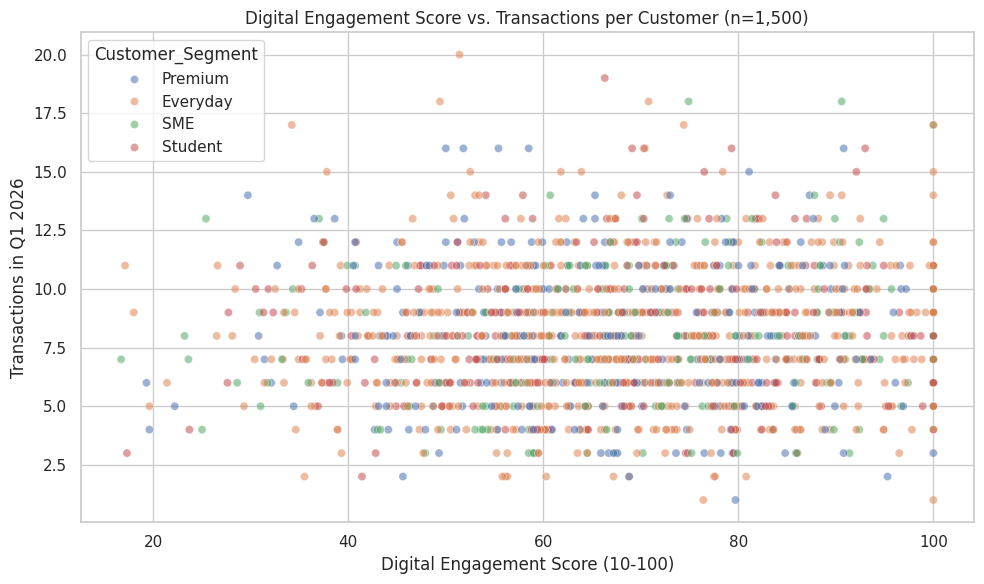

In [12]:
cust_activity = data.groupby("Customer_ID").agg(
    tx_count=("Transaction_ID", "count"),
    total_value=("Amount_NGN", "sum"),
).reset_index().merge(customers[["Customer_ID", "Digital_Engagement_Score", "Customer_Segment"]], on="Customer_ID")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=cust_activity, x="Digital_Engagement_Score", y="tx_count",
                 hue="Customer_Segment", alpha=0.55, s=35, ax=ax)
ax.set_title("Digital Engagement Score vs. Transactions per Customer (n=1,500)")
ax.set_xlabel("Digital Engagement Score (10-100)")
ax.set_ylabel("Transactions in Q1 2026")
plt.tight_layout()
plt.show()

corr = cust_activity["Digital_Engagement_Score"].corr(cust_activity["tx_count"])
print(f"Correlation (engagement score, transaction count): {corr:.3f}")
print()
print("Transactions per customer — summary:")
print(cust_activity["tx_count"].describe().round(2))

**What it shows.** One point per customer (1,500 points) — engagement score on x, transaction count on y, coloured by segment — the only chart type that shows this many individual relationships without aggregating them away.

**Why it matters.** A high engagement score is often assumed to mean a more active customer. This chart tests that assumption directly instead of asserting it.

**Business insight.** The correlation between engagement score and transaction count is close to zero (r ≈ 0.0), and the four segment colours are fully intermixed with no visible clustering. `Digital_Engagement_Score` behaves as an independent synthetic attribute, not a proxy for activity — it should not be used as a stand-in for a customer's actual transaction behaviour in any model or dashboard filter.

## 9. Risk-Review Patterns

### Visualisation 8 — Risk-review rate by hour of day

Off-hours (00:00-05:59) risk rate: 28.37 %
All other hours risk rate        : 16.68 %


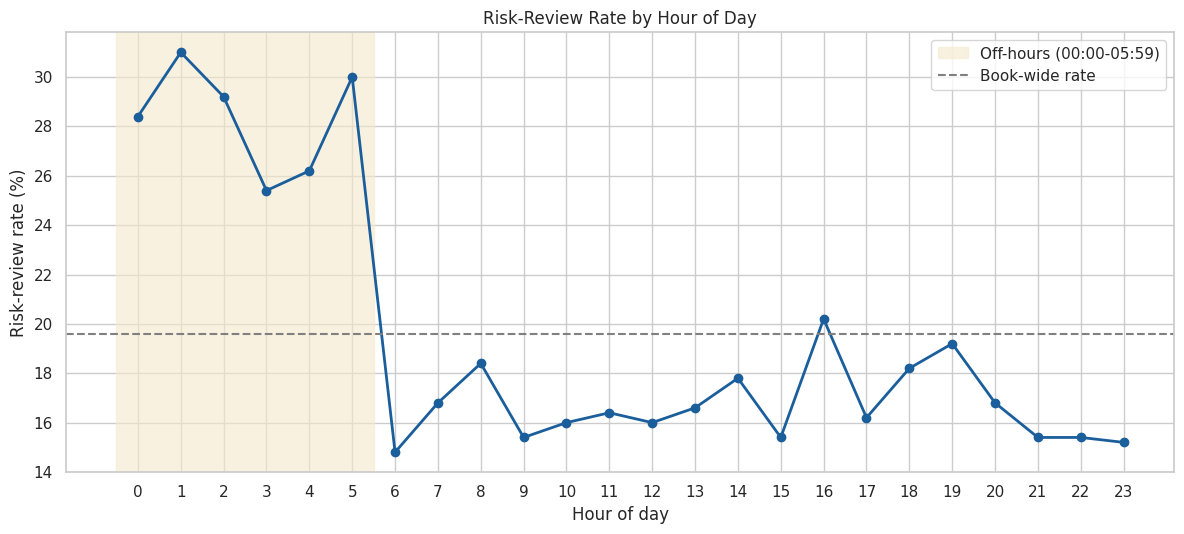

In [13]:
hourly = data.groupby("Hour").agg(
    transactions=("Transaction_ID", "count"),
    risk_rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(hourly["Hour"], hourly["risk_rate"], marker="o", color="#1B5E9C", linewidth=2)
ax.axvspan(-0.5, 5.5, color="#F6E9CC", alpha=0.6, label="Off-hours (00:00-05:59)")
ax.axhline((data.Risk_Review_Flag == "Yes").mean() * 100, color="grey", linestyle="--", label="Book-wide rate")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Risk-review rate (%)")
ax.set_title("Risk-Review Rate by Hour of Day")
ax.legend()
plt.tight_layout()
plt.show()

print("Off-hours (00:00-05:59) risk rate:", round(data[data.Hour.between(0,5)].Risk_Review_Flag.eq("Yes").mean()*100, 2), "%")
print("All other hours risk rate        :", round(data[~data.Hour.between(0,5)].Risk_Review_Flag.eq("Yes").mean()*100, 2), "%")

**What it shows.** Risk-review rate plotted across all 24 hours, with the overnight off-hours band shaded and the book-wide baseline marked.

**Why it matters.** Of every pattern tested in this notebook — segment, channel, transaction type, international status — time of day produces the single largest swing in risk-review rate, and it is a dimension the review team can act on directly (staffing, alert thresholds).

**Business insight.** The off-hours band (00:00-05:59) has a risk-review rate of 28.37%, against 16.3%-17.0% for every other six-hour block — roughly 1.6x to 1.7x higher. If the review team can only concentrate effort on one dimension, this is the one with the largest, cleanest effect.

### Visualisation 9 — Risk-review rate by transaction-amount decile

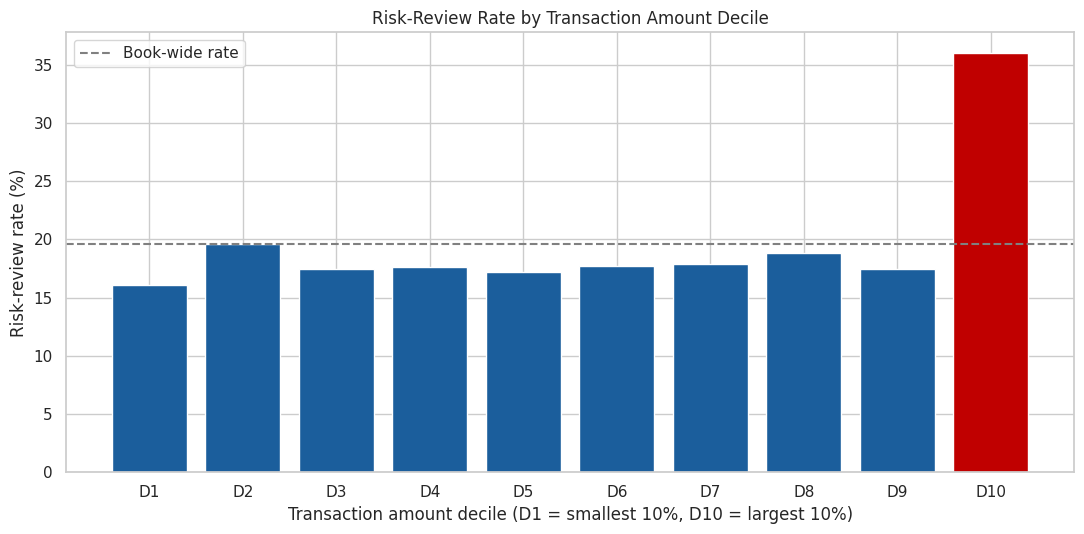

               risk_rate  min_amount  max_amount
Amount_Decile                                   
D1                 16.08      100.17      811.65
D2                 19.58      812.28    1,588.52
D3                 17.50    1,588.79    2,969.36
D4                 17.67    2,969.80    5,556.60
D5                 17.17    5,560.24   10,305.76
D6                 17.75   10,306.11   18,810.70
D7                 17.92   18,833.32   35,146.80
D8                 18.83   35,146.92   68,261.56
D9                 17.50   68,276.22  142,984.26
D10                36.00  143,262.40  693,454.45

In [14]:
decile_order = [f"D{i}" for i in range(1, 11)]
decile_stats = data.groupby("Amount_Decile", observed=True).agg(
    risk_rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100),
    min_amount=("Amount_NGN", "min"),
    max_amount=("Amount_NGN", "max"),
).reindex(decile_order)

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["#C00000" if d == "D10" else "#1B5E9C" for d in decile_stats.index]
ax.bar(decile_stats.index, decile_stats["risk_rate"], color=colors)
ax.axhline((data.Risk_Review_Flag == "Yes").mean() * 100, color="grey", linestyle="--", label="Book-wide rate")
ax.set_xlabel("Transaction amount decile (D1 = smallest 10%, D10 = largest 10%)")
ax.set_ylabel("Risk-review rate (%)")
ax.set_title("Risk-Review Rate by Transaction Amount Decile")
ax.legend()
plt.tight_layout()
plt.show()

decile_stats.round(2)

**What it shows.** The 12,000 transactions split into ten equal-sized groups by amount, from smallest (D1) to largest (D10), with the risk-review rate for each.

**Why it matters.** If risk concentrates in the largest transactions, review effort should be weighted toward high-value activity, not spread evenly.

**Business insight.** D10 (transactions ≥ NGN 143,012, the 90th percentile) has a risk-review rate around 36% — roughly double every other decile, which cluster near the book-wide baseline. Combined with the off-hours finding (Visualisation 8), the two highest-value review targets identified in this notebook are: **large transactions** and **overnight transactions** — both directly actionable as alert rules.

## 10. Summary of Findings

| # | Area | Finding |
|---|------|---------|
| 1 | Customer segments | Segment predicts headcount (47.4% Everyday), not spend — average ticket varies only ~7% across segments |
| 2 | Transaction types | Deposit has the highest average ticket (NGN 98,633); Airtime/Data the lowest (NGN 8,250) — do not pool them in one "average transaction" figure |
| 3 | Transaction amounts | Severely right-skewed (skew 3.20); mean is 4.5x the median — always report both |
| 4 | Transaction channels | Mobile App combines the largest volume share (42.52%) and the highest failure rate (10.25%) — the highest-leverage channel for an operations fix |
| 5 | Transaction status | Success rate is tight across channels (89.75%-90.85%) — failure is a platform-wide issue, not one channel |
| 6 | International transactions | Flagged at 2x the domestic rate (36.88% vs 18.88%) but only 4% of volume — a strong per-transaction signal, a small share of total review workload |
| 7 | Customer behaviour | Digital engagement score is uncorrelated with transaction activity (r ≈ 0.0) — not a usable proxy for activity |
| 8 | Risk-review patterns (time) | Off-hours transactions are flagged at 28.37%, ~1.6x every other time band — the single strongest pattern found |
| 9 | Risk-review patterns (amount) | The top amount decile is flagged at ~2x the book-wide rate — risk concentrates in high-value transactions |

All nine visualisations and their underlying numbers reconcile to the SQL results in `FinTrust_Week2_SQL_Analysis.sql` and to the KPI baselines in the Week 1 KPI Definition Sheet — see the Week 2 Documentation for the full cross-reference.

**Reminder.** `Risk_Review_Flag` is a synthetic educational label. Every risk-related finding above describes review-queue workload patterns, not a fraud determination.